In [ ]:
# E-COMMERCE SALES ANALYTICS
import pandas as pd

# =========================
# 1. LOAD DATA
# =========================

customers = pd.read_csv('/content/customers.csv')
categories = pd.read_csv('/content/categories.csv')
suppliers = pd.read_csv('/content/suppliers.csv')
products = pd.read_csv('/content/products.csv')
orders = pd.read_csv('/content/orders.csv')
order_items = pd.read_csv('/content/order_items.csv')
payments = pd.read_csv('/content/payments.csv')
shipments = pd.read_csv('/content/shipments.csv')


# =========================
# 2. DATA OVERVIEW
# =========================

tables = {
    'customers': customers,
    'categories': categories,
    'suppliers': suppliers,
    'products': products,
    'orders': orders,
    'order_items': order_items,
    'payments': payments,
    'shipments': shipments
}

for name, df in tables.items():
    print(f"{name}: {df.shape}")


# =========================
# 3. DATA TYPE
# =========================

orders['order_date'] = pd.to_datetime(orders['order_date'])
payments['payment_date'] = pd.to_datetime(payments['payment_date'])
shipments['shipping_date'] = pd.to_datetime(shipments['shipping_date'])
shipments['delivery_date'] = pd.to_datetime(shipments['delivery_date'])


# =========================
# 4. GABUNG DATA UTAMA
# =========================

df = order_items.merge(
    orders[['order_id', 'customer_id', 'order_date', 'order_status']],
    on='order_id',
    how='left'
)

df = df.merge(
    products[
        ['product_id', 'product_name', 'category_id',
         'supplier_id', 'brand', 'cost_price']
    ],
    on='product_id',
    how='left'
)

df = df.merge(
    customers[
        ['customer_id', 'customer_name', 'gender',
         'birth_date', 'city', 'province', 'customer_segment']
    ],
    on='customer_id',
    how='left'
)

df = df.merge(
    categories[
        ['category_id', 'category_name']
    ],
    on='category_id',
    how='left'
)


# =========================
# 5. HITUNG METRIK
# =========================

df['revenue'] = (
    df['quantity']
    * df['unit_price']
    * (1 - df['discount'])
)

df['profit'] = (
    df['quantity']
    * (
        df['unit_price'] * (1 - df['discount'])
        - df['cost_price']
    )
)

df['margin'] = df['profit'] / df['revenue']


# =========================
# 6. FILTER COMPLETED
# =========================

completed = df[df['order_status'] == 'Completed'].copy()


# =========================
# 7. BUSINESS OVERVIEW
# =========================

total_revenue = completed['revenue'].sum()
total_profit = completed['profit'].sum()
profit_margin = total_profit / total_revenue

print("\n=== BUSINESS OVERVIEW ===")
print(f"Revenue : Rp{total_revenue:,.0f}")
print(f"Profit  : Rp{total_profit:,.0f}")
print(f"Margin  : {profit_margin:.2%}")


# =========================
# 8. REVENUE BY CATEGORY
# =========================

revenue_category = (
    completed
    .groupby('category_name')['revenue']
    .sum()
    .sort_values(ascending=False)
)

print("\n=== TOP CATEGORY ===")
print(revenue_category.head(10))


# =========================
# 9. TOP PRODUCTS
# =========================

revenue_product = (
    completed
    .groupby('product_name')['revenue']
    .sum()
    .sort_values(ascending=False)
)

print("\n=== TOP PRODUCTS ===")
print(revenue_product.head(10))


# =========================
# 10. REVENUE BY CITY
# =========================

revenue_city = (
    completed
    .groupby('city')['revenue']
    .sum()
    .sort_values(ascending=False)
)

print("\n=== TOP CITY ===")
print(revenue_city.head(10))


# =========================
# 11. CUSTOMER ANALYSIS
# =========================

customer_analysis = (
    completed
    .groupby(
        ['customer_id', 'customer_name', 'city']
    )
    .agg(
        revenue=('revenue', 'sum'),
        profit=('profit', 'sum'),
        orders=('order_id', 'nunique')
    )
    .sort_values('revenue', ascending=False)
)

print("\n=== TOP CUSTOMERS ===")
print(customer_analysis.head(10))


# =========================
# 12. MONTHLY TREND
# =========================

monthly_revenue = (
    completed
    .assign(month=completed['order_date'].dt.to_period('M'))
    .groupby('month')['revenue']
    .sum()
)

print("\n=== MONTHLY REVENUE ===")
print(monthly_revenue)


# =========================
# 13. ORDER STATUS
# =========================

order_status = (
    orders['order_status']
    .value_counts()
)

print("\n=== ORDER STATUS ===")
print(order_status)


print("\nEDA SELESAI")

customers: (20000, 8)
categories: (50, 2)
suppliers: (500, 4)
products: (1000, 8)
orders: (100000, 4)
order_items: (271636, 6)
payments: (100000, 5)
shipments: (100000, 7)

=== BUSINESS OVERVIEW ===
Revenue : Rp2,559,379,566,250
Profit  : Rp711,454,129,926
Margin  : 27.80%

=== TOP CATEGORY ===
category_name
Category 47    8.065636e+10
Category 37    7.304462e+10
Category 17    7.293154e+10
Category 40    6.842307e+10
Toys           6.785788e+10
Electronics    6.705130e+10
Category 49    6.658910e+10
Category 45    6.484611e+10
Sports         6.420271e+10
Category 34    6.402501e+10
Name: revenue, dtype: float64

=== TOP PRODUCTS ===
product_name
Product 769    6.584605e+09
Product 577    6.575396e+09
Product 674    6.314903e+09
Product 996    6.128155e+09
Product 380    6.071037e+09
Product 136    6.049716e+09
Product 361    6.041498e+09
Product 138    5.904731e+09
Product 938    5.829672e+09
Product 766    5.825081e+09
Name: revenue, dtype: float64

=== TOP CITY ===
city
Bandung     

In [ ]:
# ==========================================
# 1. REVENUE & PROFIT PER CATEGORY
# ==========================================

category_performance = (
    completed
    .groupby('category_name')
    .agg(
        revenue=('revenue', 'sum'),
        profit=('profit', 'sum')
    )
)

category_performance['margin'] = (
    category_performance['profit']
    / category_performance['revenue']
)

category_performance = (
    category_performance
    .sort_values('revenue', ascending=False)
)

print("=== CATEGORY PERFORMANCE ===")
display(category_performance.head(10))


# ==========================================
# 2. CUSTOMER SEGMENT
# ==========================================

segment_performance = (
    completed
    .groupby('customer_segment')
    .agg(
        revenue=('revenue', 'sum'),
        profit=('profit', 'sum'),
        customers=('customer_id', 'nunique'),
        orders=('order_id', 'nunique')
    )
)

segment_performance['avg_revenue_per_customer'] = (
    segment_performance['revenue']
    / segment_performance['customers']
)

segment_performance = (
    segment_performance
    .sort_values('revenue', ascending=False)
)

print("\n=== CUSTOMER SEGMENT ===")
display(segment_performance)


# ==========================================
# 3. REPEAT PURCHASE DISTRIBUTION
# ==========================================

customer_orders = (
    completed
    .groupby('customer_id')['order_id']
    .nunique()
)

repeat_distribution = (
    customer_orders
    .value_counts()
    .sort_index()
)

print("\n=== ORDER FREQUENCY PER CUSTOMER ===")
display(repeat_distribution.head(15))


# ==========================================
# 4. MONTHLY REVENUE GROWTH
# ==========================================
monthly = (
    completed
    .assign(
        month=completed['order_date'].dt.to_period('M')
    )
    .groupby('month')
    .agg(
        revenue=('revenue', 'sum'),
        profit=('profit', 'sum'),
        orders=('order_id', 'nunique')
    )
)

monthly['revenue_growth'] = (
    monthly['revenue'].pct_change() * 100
)

print("\n=== MONTHLY PERFORMANCE ===")
display(monthly)

=== CATEGORY PERFORMANCE ===


,revenue,profit,margin
category_name,,,
Category 47,8.065636e+10,2.277880e+10,0.282418
Category 37,7.304462e+10,2.033484e+10,0.278389
Category 17,7.293154e+10,1.984931e+10,0.272164
Category 40,6.842307e+10,1.932140e+10,0.282381
Toys,6.785788e+10,1.921146e+10,0.283113
Electronics,6.705130e+10,2.229601e+10,0.332522
Category 49,6.658910e+10,1.918580e+10,0.288122
Category 45,6.484611e+10,1.910924e+10,0.294686
Sports,6.420271e+10,1.701380e+10,0.265001



=== CUSTOMER SEGMENT ===


,revenue,profit,customers,orders,avg_revenue_per_customer
customer_segment,,,,,
Regular,1.419226e+12,3.941605e+11,8987,49748,1.579198e+08
Silver,6.417479e+11,1.785438e+11,4127,22612,1.554998e+08
Gold,3.729473e+11,1.039995e+11,2397,13122,1.555892e+08
Platinum,1.254589e+11,3.475022e+10,831,4474,1.509734e+08



=== ORDER FREQUENCY PER CUSTOMER ===


,count
order_id,
1,2927
2,2426
3,2005
4,1603
5,1359
6,1045
7,930
8,749
9,643



=== MONTHLY PERFORMANCE ===


,revenue,profit,orders,revenue_growth
month,,,,
2024-01,1.091037e+11,3.009784e+10,3821,NaN
2024-02,1.000152e+11,2.760174e+10,3564,-8.330142
2024-03,1.080504e+11,2.998147e+10,3792,8.033993
2024-04,1.069273e+11,2.991291e+10,3740,-1.039453
2024-05,1.092797e+11,3.054290e+10,3855,2.200026
2024-06,1.035342e+11,2.893460e+10,3665,-5.257619
2024-07,1.068565e+11,2.993675e+10,3808,3.208938
2024-08,1.124271e+11,3.101940e+10,3864,5.213127
2024-09,1.052604e+11,2.920986e+10,3707,-6.374574


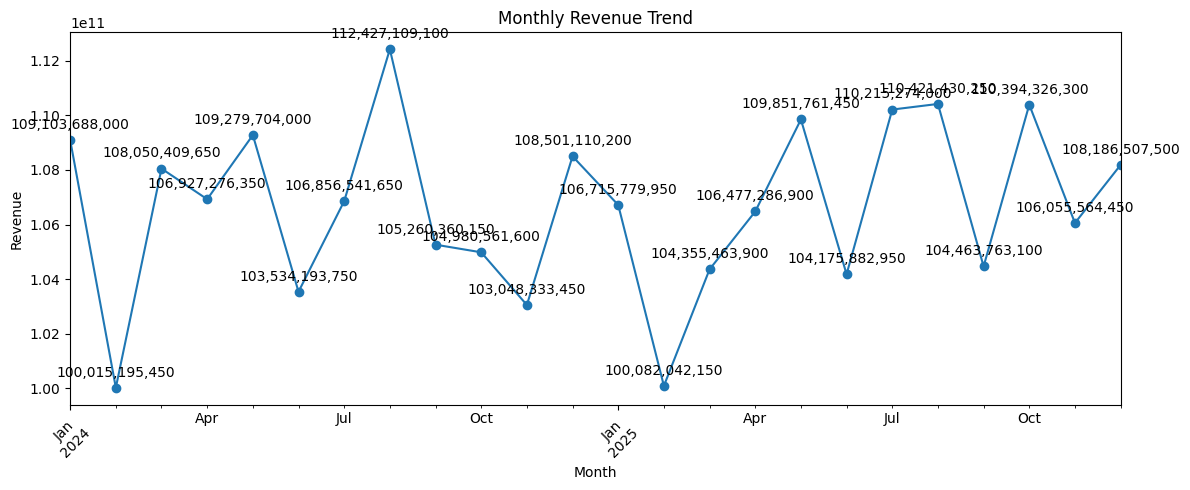

In [ ]:
import matplotlib.pyplot as plt

monthly['revenue'].plot(
    kind='line',
    figsize=(12, 5),
    title='Monthly Revenue Trend',
    marker='o'
)

# Menambahkan angka di setiap titik
for x, y in zip(monthly.index, monthly['revenue']):
    plt.annotate(
        f'{y:,.0f}',
        (x, y),
        textcoords='offset points',
        xytext=(0, 8),
        ha='center'
    )

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

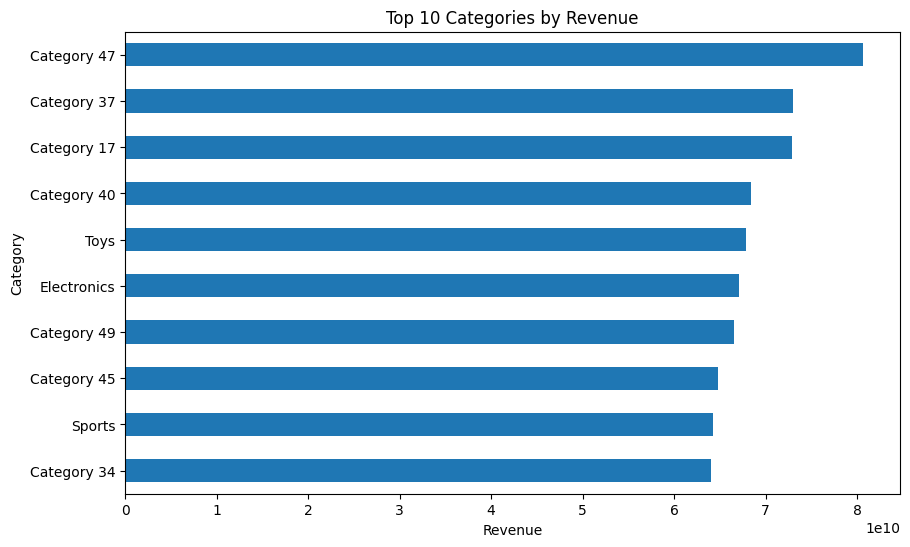

In [ ]:
category_performance['revenue'].head(10).sort_values().plot(
    kind='barh',
    figsize=(10, 6),
    title='Top 10 Categories by Revenue'
)

plt.xlabel('Revenue')
plt.ylabel('Category')
plt.show()

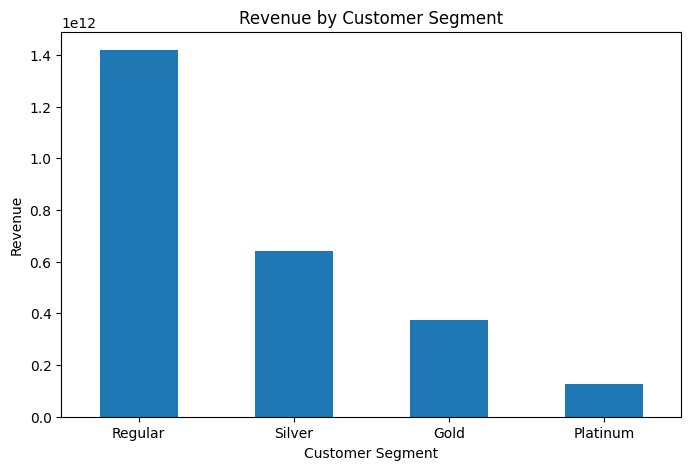

In [ ]:
segment_performance['revenue'].plot(
    kind='bar',
    figsize=(8, 5),
    title='Revenue by Customer Segment'
)

plt.xlabel('Customer Segment')
plt.ylabel('Revenue')
plt.xticks(rotation=0)
plt.show()

In [ ]:
# ==========================================
# INVESTIGASI REVENUE TERTINGGI & TERENDAH
# ==========================================

monthly_analysis = (
    completed
    .assign(
        month=completed['order_date'].dt.to_period('M')
    )
    .groupby('month')
    .agg(
        revenue=('revenue', 'sum'),
        orders=('order_id', 'nunique'),
        items=('quantity', 'sum'),
        customers=('customer_id', 'nunique')
    )
)

monthly_analysis['avg_order_value'] = (
    monthly_analysis['revenue']
    / monthly_analysis['orders']
)

print("=== MONTHLY ANALYSIS ===")
display(monthly_analysis)

print("\n=== TOP REVENUE MONTH ===")
display(
    monthly_analysis
    .sort_values('revenue', ascending=False)
    .head(3)
)

print("\n=== LOWEST REVENUE MONTH ===")
display(
    monthly_analysis
    .sort_values('revenue')
    .head(3)
)

=== MONTHLY ANALYSIS ===


,revenue,orders,items,customers,avg_order_value
month,,,,,
2024-01,1.091037e+11,3821,31529,3196,2.855370e+07
2024-02,1.000152e+11,3564,28950,3000,2.806262e+07
2024-03,1.080504e+11,3792,31058,3228,2.849431e+07
2024-04,1.069273e+11,3740,30331,3142,2.859018e+07
2024-05,1.092797e+11,3855,31291,3217,2.834752e+07
2024-06,1.035342e+11,3665,29658,3123,2.824944e+07
2024-07,1.068565e+11,3808,30678,3187,2.806107e+07
2024-08,1.124271e+11,3864,32034,3237,2.909604e+07
2024-09,1.052604e+11,3707,30317,3125,2.839503e+07



=== TOP REVENUE MONTH ===


,revenue,orders,items,customers,avg_order_value
month,,,,,
2024-08,1.124271e+11,3864,32034,3237,2.909604e+07
2025-08,1.104214e+11,3838,31711,3249,2.877057e+07
2025-10,1.103943e+11,3889,31570,3223,2.838630e+07



=== LOWEST REVENUE MONTH ===


,revenue,orders,items,customers,avg_order_value
month,,,,,
2024-02,1.000152e+11,3564,28950,3000,2.806262e+07
2025-02,1.000820e+11,3434,28277,2946,2.914445e+07
2024-11,1.030483e+11,3607,29485,3052,2.856899e+07


In [ ]:
# ==========================================
# PRODUCT & CATEGORY DEEP ANALYSIS
# ==========================================

category_analysis = (
    completed
    .groupby('category_name')
    .agg(
        revenue=('revenue', 'sum'),
        profit=('profit', 'sum'),
        quantity=('quantity', 'sum'),
        orders=('order_id', 'nunique'),
        customers=('customer_id', 'nunique')
    )
)

category_analysis['margin'] = (
    category_analysis['profit']
    / category_analysis['revenue']
)

category_analysis['avg_order_value'] = (
    category_analysis['revenue']
    / category_analysis['orders']
)

category_analysis = category_analysis.sort_values(
    'margin',
    ascending=False
)

display(category_analysis.head(10))

,revenue,profit,quantity,orders,customers,margin,avg_order_value
category_name,,,,,,,
Category 41,2.766823e+10,9.456946e+09,9833,3212,2769,0.341798,8.614020e+06
Electronics,6.705130e+10,2.229601e+10,14500,4784,3869,0.332522,1.401574e+07
Category 44,5.005257e+10,1.651656e+10,13299,4388,3579,0.329984,1.140669e+07
Category 28,4.405829e+10,1.407949e+10,11577,3816,3209,0.319565,1.154567e+07
Category 21,3.925572e+10,1.247877e+10,12998,4237,3510,0.317884,9.264980e+06
Category 48,3.666526e+10,1.153977e+10,9788,3188,2771,0.314733,1.150102e+07
Category 50,3.711306e+10,1.160480e+10,10775,3583,3054,0.312688,1.035810e+07
Category 32,4.264181e+10,1.284587e+10,12540,4107,3434,0.301251,1.038272e+07
Category 14,5.182784e+10,1.544725e+10,15720,5166,4120,0.298049,1.003249e+07
